# 练习1

In [68]:
import pandas as pd
mulitindex_df = pd.DataFrame({'省份':['河北省','河北省','河北省','河南省','河南省','河北省','河南省','河南省'],
                              '城市':['石家庄市','唐山市','邯郸市','秦皇岛市','郑州市','开封市','洛阳市','新乡市'],
                              '占地面积':[15848,13472,12073.8,7813,7446,6444,15230,8269]} )             
mulitindex_df

,省份,城市,占地面积
0,河北省,石家庄市,15848.0
1,河北省,唐山市,13472.0
2,河北省,邯郸市,12073.8
3,河南省,秦皇岛市,7813.0
4,河南省,郑州市,7446.0
5,河北省,开封市,6444.0
6,河南省,洛阳市,15230.0
7,河南省,新乡市,8269.0


### 1、按照省份对数据分组，并进行占地面积求和统计

In [69]:
data_groupby_province = mulitindex_df.groupby('省份').agg({
    '占地面积':'sum'
})
data_groupby_province

,占地面积
省份,
河北省,47837.8
河南省,38758.0


### 2、按照省份和城市对数据分组，并进行占地面积求和统计

In [70]:
data_groupby_province_city = mulitindex_df.groupby(['省份','城市']).agg({
    '占地面积':'sum'    
})
data_groupby_province_city


占地面积
省份   城市              
河北省 唐山市     13472.0
       开封市      6444.0
       石家庄市   15848.0
       邯郸市     12073.8
河南省 新乡市      8269.0
       洛阳市     15230.0
       秦皇岛市    7813.0
       郑州市      7446.0

附加：

In [71]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
df = pd.DataFrame({'year': [2019, 2020,2021, 2020, 2022],
                   'month': [3, 9, 6, 9, 12],
                   'day': [4, 2, 21, 2, 15]})
print('原始数据：\n', df)

原始数据：
    year  month  day
0  2019      3    4
1  2020      9    2
2  2021      6   21
3  2020      9    2
4  2022     12   15


In [72]:
df = pd.to_datetime(df)
df.dt.year
df.dt.month
df.dt.day


0     4
1     2
2    21
3     2
4    15
dtype: int32

# 练习2

In [73]:
city_df = pd.read_excel("./city.xlsx",index_col=0)
city_df

,ID,Name,CountryCode,District,Population
0,1,Kabul,AFG,Kabol,1780000
1,2,Qandahar,AFG,Qandahar,237500
2,3,Herat,AFG,Herat,186800
3,4,Mazar-e-Sharif,AFG,Balkh,127800
4,5,Amsterdam,NLD,Noord-Holland,731200
...,...,...,...,...,...
4074,4075,Khan Yunis,PSE,Khan Yunis,123175
4075,4076,Hebron,PSE,Hebron,119401
4076,4077,Jabaliya,PSE,North Gaza,113901
4077,4078,Nablus,PSE,Nablus,100231


利用所学的方法及属性，熟悉上面的数据

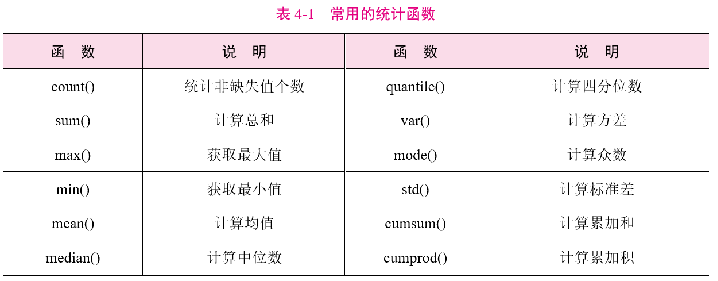

In [74]:
city_df.count()

ID             4079
Name           4079
CountryCode    4079
District       4075
Population     4079
dtype: int64

In [75]:
city_df['Population'].sum()

np.int64(1429559884)

In [ ]:
max_population = city_df['Population'].max()
min_population = city_df['Population'].min()
max_population_row = city_df[city_df['Population'] == max_population]
min_population_row = city_df[city_df['Population'] == min_population]


,ID,Name,CountryCode,District,Population
1023,1024,Mumbai (Bombay),IND,Maharashtra,10500000


In [93]:
city_df['Population'].describe()

count    4.079000e+03
mean     3.504682e+05
std      7.237757e+05
min      4.200000e+01
25%      1.147890e+05
50%      1.670510e+05
75%      3.106385e+05
max      1.050000e+07
Name: Population, dtype: float64

# 练习3

按照占地面积列数据对整体数据进行排序(分别尝试升序和降序排序)

In [91]:
ascending_df = mulitindex_df.sort_values(by='占地面积',ascending=True)
descending_df = mulitindex_df.sort_values(by='占地面积',ascending=False)
descending_df.set_index('省份')


,城市,占地面积
省份,,
河北省,石家庄市,15848.0
河南省,洛阳市,15230.0
河北省,唐山市,13472.0
河北省,邯郸市,12073.8
河南省,新乡市,8269.0
河南省,秦皇岛市,7813.0
河南省,郑州市,7446.0
河北省,开封市,6444.0


在降序排序结果后，增加一列排名列，按顺序排名

In [78]:
descending_df['排名'] = descending_df['占地面积'].rank(method='first',ascending=False).astype(int)
descending_df

,省份,城市,占地面积,排名
0,河北省,石家庄市,15848.0,1
6,河南省,洛阳市,15230.0,2
1,河北省,唐山市,13472.0,3
2,河北省,邯郸市,12073.8,4
7,河南省,新乡市,8269.0,5
3,河南省,秦皇岛市,7813.0,6
4,河南省,郑州市,7446.0,7
5,河北省,开封市,6444.0,8


# 练习4

In [79]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
product_df = pd.read_excel('产品订单信息表.xlsx')
product_df

,订单ID,性别,产品类型,消费金额
0,2022030801,男,手机,3500
1,2022030802,男,电脑,5500
2,2022030803,女,手机,7000
3,2022030804,女,手机,3500
4,2022030805,男,手机,3500
5,2022030806,女,电脑,5500
6,2022030807,男,电脑,11000
7,2022030808,女,手机,3500
8,2022030809,女,手机,10500
9,2022030810,女,电脑,5500


In [80]:
import pandas as pd
pd.set_option('display.unicode.east_asian_width', True)
product2_df = pd.read_excel('产品订单信息表.xlsx')
product2_df


,订单ID,性别,产品类型,消费金额
0,2022030801,男,手机,3500
1,2022030802,男,电脑,5500
2,2022030803,女,手机,7000
3,2022030804,女,手机,3500
4,2022030805,男,手机,3500
5,2022030806,女,电脑,5500
6,2022030807,男,电脑,11000
7,2022030808,女,手机,3500
8,2022030809,女,手机,10500
9,2022030810,女,电脑,5500
